In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("train.csv")
df.shape

In [3]:
defect_cols = [
    'Pastry',
    'Z_Scratch',
    'K_Scatch',
    'Stains',
    'Dirtiness',
    'Bumps',
    'Other_Faults'
]

# Number of defects in each row
df['Defect_Sum'] = df[defect_cols].sum(axis=1)

# Create Defect_Type
df['Defect_Type'] = 'No_Defect'

# Rows having exactly one defect
mask = df['Defect_Sum'] == 1

df.loc[mask, 'Defect_Type'] = (
    df.loc[mask, defect_cols]
      .idxmax(axis=1)
)

# Drop rows having multiple defects
df = df[df['Defect_Sum'] <= 1].copy()

# Remove helper column
df.drop(columns=['Defect_Sum'], inplace=True)

print(df['Defect_Type'].value_counts())

Defect_Type
Other_Faults    6540
Bumps           4761
K_Scatch        3411
Pastry          1465
Z_Scratch       1150
No_Defect        818
Stains           568
Dirtiness        485
Name: count, dtype: int64


In [6]:
df.drop(columns=['Other_Faults','Bumps','Dirtiness','Stains','K_Scatch','Z_Scratch','Pastry','id'], inplace=True)
df.shape
print("-----------------------------")
df.info()

-----------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 19198 entries, 0 to 19218
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              19198 non-null  int64  
 1   X_Maximum              19198 non-null  int64  
 2   Y_Minimum              19198 non-null  int64  
 3   Y_Maximum              19198 non-null  int64  
 4   Pixels_Areas           19198 non-null  int64  
 5   X_Perimeter            19198 non-null  int64  
 6   Y_Perimeter            19198 non-null  int64  
 7   Sum_of_Luminosity      19198 non-null  int64  
 8   Minimum_of_Luminosity  19198 non-null  int64  
 9   Maximum_of_Luminosity  19198 non-null  int64  
 10  Length_of_Conveyer     19198 non-null  int64  
 11  TypeOfSteel_A300       19198 non-null  int64  
 12  TypeOfSteel_A400       19198 non-null  int64  
 13  Steel_Plate_Thickness  19198 non-null  int64  
 14  Edges_Index            19198 

In [7]:
# Drop invalid rows:
# (0,0) -> no steel type
# (1,1) -> both steel types selected

df = df[
    df['TypeOfSteel_A300'] != df['TypeOfSteel_A400']
].copy()

# Reverse one-hot encoding
df['Steel_Type'] = df['TypeOfSteel_A300'].map({
    1: 'A300',
    0: 'A400'
})

# Remove old columns
df.drop(
    columns=[
        'TypeOfSteel_A300',
        'TypeOfSteel_A400'
    ],
    inplace=True
)

print(df['Steel_Type'].value_counts())

Steel_Type
A400    11440
A300     7738
Name: count, dtype: int64


In [9]:
df.shape
print("-----------------------------")
df.info()

-----------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 19178 entries, 0 to 19218
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              19178 non-null  int64  
 1   X_Maximum              19178 non-null  int64  
 2   Y_Minimum              19178 non-null  int64  
 3   Y_Maximum              19178 non-null  int64  
 4   Pixels_Areas           19178 non-null  int64  
 5   X_Perimeter            19178 non-null  int64  
 6   Y_Perimeter            19178 non-null  int64  
 7   Sum_of_Luminosity      19178 non-null  int64  
 8   Minimum_of_Luminosity  19178 non-null  int64  
 9   Maximum_of_Luminosity  19178 non-null  int64  
 10  Length_of_Conveyer     19178 non-null  int64  
 11  Steel_Plate_Thickness  19178 non-null  int64  
 12  Edges_Index            19178 non-null  float64
 13  Empty_Index            19178 non-null  float64
 14  Square_Index           19178 

In [10]:
df.head(5)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Defect_Type,Steel_Type
0,584,590,909972,909977,16,8,5,2274,113,140,...,1.0000,0.0,1.2041,0.9031,0.6990,-0.5000,-0.0104,0.1417,Stains,A400
1,808,816,728350,728372,433,20,54,44478,70,111,...,1.0000,1.0,2.6365,0.7782,1.7324,0.7419,-0.2997,0.9491,Other_Faults,A300
2,39,192,2212076,2212144,11388,705,420,1311391,29,141,...,0.3857,0.0,4.0564,2.1790,2.2095,-0.0105,-0.0944,1.0000,K_Scatch,A400
3,781,789,3353146,3353173,210,16,29,3202,114,134,...,0.9310,1.0,2.3222,0.7782,1.4314,0.6667,-0.0402,0.4025,K_Scatch,A400
4,1540,1560,618457,618502,521,72,67,48231,82,111,...,0.9861,1.0,2.7694,1.4150,1.8808,0.9158,-0.2455,0.9998,Other_Faults,A400


In [ ]:
# df.to_csv("steel_cleaned.csv", index=False)

In [ ]:

steel_encoder = LabelEncoder()
defect_encoder = LabelEncoder()

df['Steel_Type'] = steel_encoder.fit_transform(df['Steel_Type'])
df['Defect_Type'] = defect_encoder.fit_transform(df['Defect_Type'])

print("Steel Mapping:")
print(dict(enumerate(steel_encoder.classes_)))

print("\nDefect Mapping:")
print(dict(enumerate(defect_encoder.classes_)))

Steel Mapping:
{0: 'A300', 1: 'A400'}

Defect Mapping:
{0: 'Bumps', 1: 'Dirtiness', 2: 'K_Scatch', 3: 'No_Defect', 4: 'Other_Faults', 5: 'Pastry', 6: 'Stains', 7: 'Z_Scratch'}


In [12]:
X = df.drop('Defect_Type', axis=1)
y = df['Defect_Type']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,   # 70-30 split
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nTrain Class Distribution:")
print(y_train.value_counts())

print("\nTest Class Distribution:")
print(y_test.value_counts())

X_train shape: (13424, 26)
X_test shape : (5754, 26)

Train Class Distribution:
Defect_Type
4    4576
0    3333
2    2376
5    1025
7     805
3     573
6     397
1     339
Name: count, dtype: int64

Test Class Distribution:
Defect_Type
4    1962
0    1428
2    1019
5     439
7     345
3     245
6     170
1     146
Name: count, dtype: int64


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 0.5623913799096281
              precision    recall  f1-score   support

           0       0.51      0.52      0.51      1428
           1       0.50      0.09      0.15       146
           2       0.88      0.89      0.89      1019
           3       0.00      0.00      0.00       245
           4       0.46      0.62      0.53      1962
           5       0.40      0.15      0.22       439
           6       0.74      0.82      0.78       170
           7       0.64      0.46      0.54       345

    accuracy                           0.56      5754
   macro avg       0.52      0.44      0.45      5754
weighted avg       0.54      0.56      0.54      5754



c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

DT Accuracy: 0.4608967674661105
              precision    recall  f1-score   support

           0       0.42      0.41      0.41      1428
           1       0.19      0.19      0.19       146
           2       0.83      0.82      0.82      1019
           3       0.07      0.08      0.08       245
           4       0.41      0.41      0.41      1962
           5       0.24      0.26      0.25       439
           6       0.63      0.62      0.63       170
           7       0.46      0.45      0.45       345

    accuracy                           0.46      5754
   macro avg       0.41      0.41      0.41      5754
weighted avg       0.46      0.46      0.46      5754



In [ ]:

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGB Accuracy: 0.5832464372610358
              precision    recall  f1-score   support

           0       0.53      0.55      0.54      1428
           1       0.50      0.15      0.23       146
           2       0.89      0.90      0.90      1019
           3       0.00      0.00      0.00       245
           4       0.48      0.60      0.53      1962
           5       0.44      0.24      0.31       439
           6       0.72      0.85      0.78       170
           7       0.65      0.63      0.64       345

    accuracy                           0.58      5754
   macro avg       0.53      0.49      0.49      5754
weighted avg       0.56      0.58      0.56      5754



c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shreyesh Singh\Genvs\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

print(results.sort_values("Accuracy", ascending=False))

           Model  Accuracy
2        XGBoost  0.583246
1  Random Forest  0.562391
0  Decision Tree  0.460897


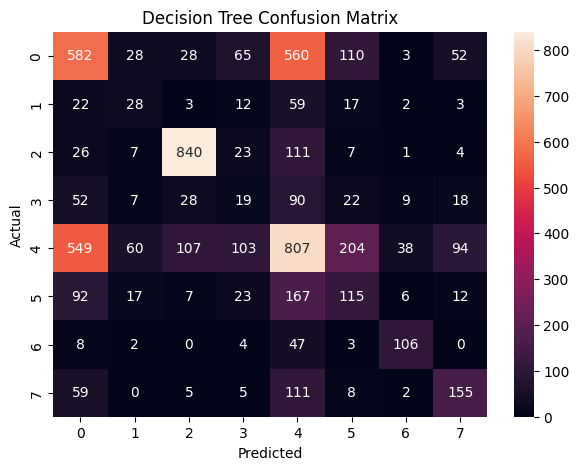

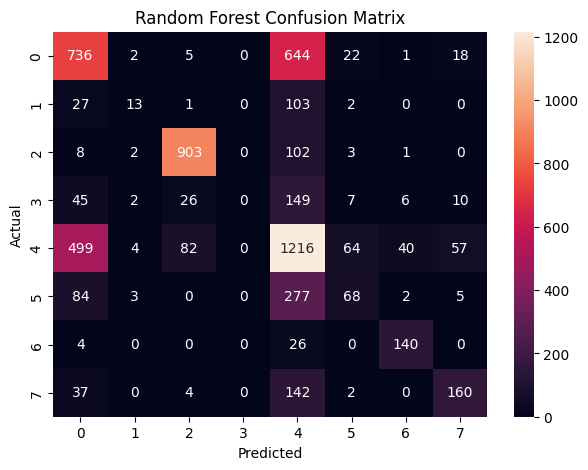

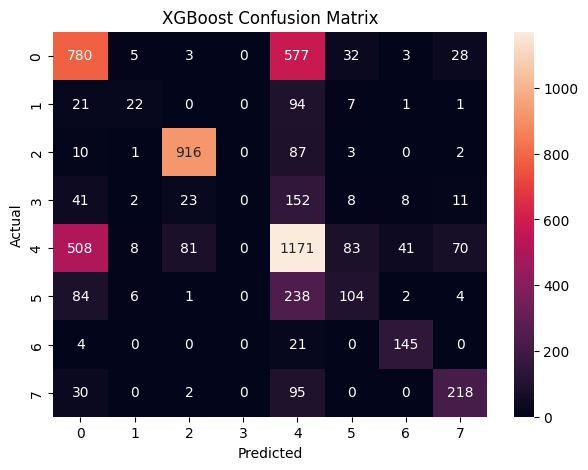

In [ ]:

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    plt.figure(figsize=(7,5))

    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d'
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Defect_Type': y
})

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

Explained Variance Ratio: [0.37000315 0.11800689]


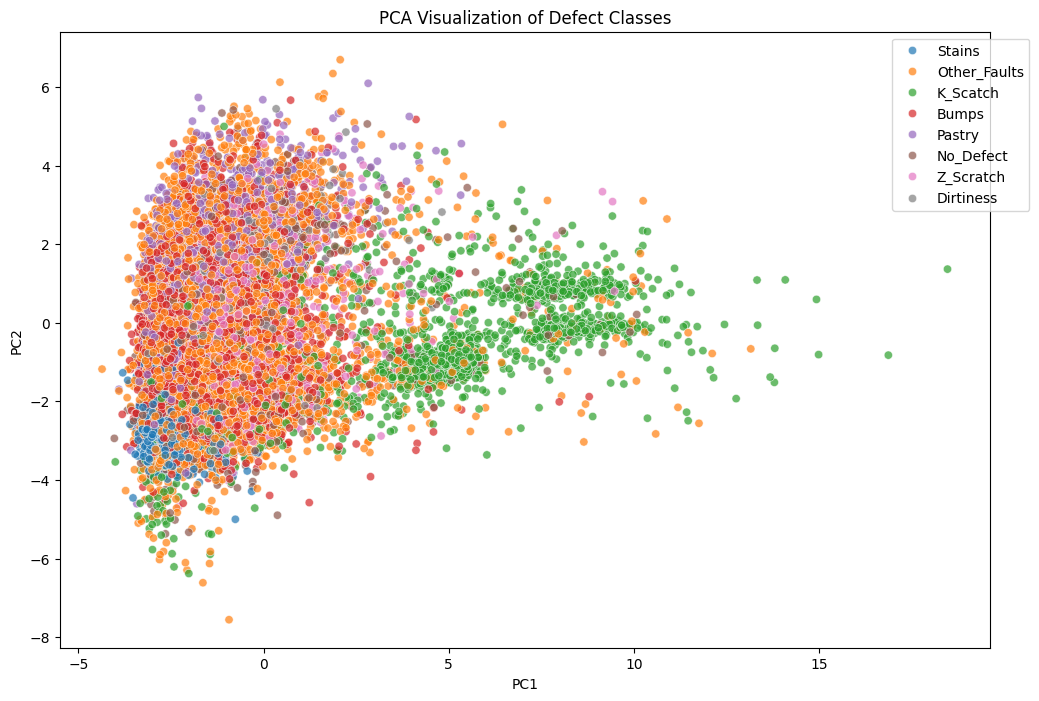

In [21]:
pca_df['Defect_Name'] = (
    defect_encoder.inverse_transform(
        pca_df['Defect_Type']
    )
)

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Defect_Name',
    alpha=0.7
)

plt.title("PCA Visualization of Defect Classes")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
# Confusion matrix analysis and PCA visualization both indicate poor class separability among certain defect categories. Therefore, a controlled 
# experiment was performed by removing the most overlapping classes (Dirtiness and Pastry) and retraining the model.